In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
%matplotlib inline

In [ ]:
data = pd.read_csv("/content/1MODUL2.csv")
data

,Country Name,GNI per capita(usd),"Unemployment, total (% of total labor force)",Current health expenditure (% of GDP),Urban population (% of total population),"School enrollment, secondary (% gross)","Life expectancy at birth, total (years)"
0,Africa Eastern and Southern,1467.949770,7.964493,5.865553,37.323699,43.845379,62.454590
1,Africa Western and Central,1748.719321,4.524016,4.140713,48.454806,46.538330,56.988657
2,Angola,1640.000000,15.799000,2.960106,67.460000,52.543770,61.643000
3,Albania,6100.000000,12.473000,7.267318,62.969000,97.665031,76.463000
4,Arab World,6404.608605,10.783297,5.327657,59.294886,69.929779,70.814483
...,...,...,...,...,...,...,...
186,Uzbekistan,1980.000000,5.345000,7.740000,50.427000,86.056240,70.862000
187,St. Vincent and the Grenadines,8490.000000,20.279000,5.362521,53.452000,129.439684,69.629000
188,Viet Nam,3590.000000,2.385000,4.593464,38.052000,96.066743,73.618000
189,Vanuatu,3350.000000,4.734000,4.373378,25.665000,57.864090,70.449000


Источник данных:https://datatopics.worldbank.org/world-development-indicators.

Данные представляют собой экономические, социальные и демографические индикаторы стран за 2021 год.

В выборку входят 191 страна и 7 показателей.
В качестве целевой переменной выбрана Life expectancy at birth, total (years): Ожидаемая продолжительность жизни.

Объясняющие переменные:

1.   GNI per capita (USD): доход на душу населения.
2.   Unemployment, total (% of total labor force): уровень безработицы.
3.   Current health expenditure (% of GDP): расходы на здравоохранение.
4.   Urban population (% of total population): доля городского населения.
5.   School enrollment, secondary (% gross): охват учащихся в средней школе.


Эти показатели выбраны, так как логически связаны с ожидаемой продолжительностью жизни.
Гипотеза: более высокий доход, расходы на медицину и образование увеличивают продолжительность жизни, тогда как высокий уровень безработицы оказывает отрицательное влияние.


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 7 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country Name                                  191 non-null    object 
 1   GNI per capita(usd)                           191 non-null    float64
 2   Unemployment, total (% of total labor force)  191 non-null    float64
 3   Current health expenditure (% of GDP)         191 non-null    float64
 4   Urban population (% of total population)      191 non-null    float64
 5   School enrollment, secondary (% gross)        191 non-null    float64
 6   Life expectancy at birth, total (years)       191 non-null    float64
dtypes: float64(6), object(1)
memory usage: 10.6+ KB


In [ ]:
from sklearn.preprocessing import StandardScaler

feat = ['GNI per capita(usd)',
        'Unemployment, total (% of total labor force)',
        'Current health expenditure (% of GDP)',
        'Urban population (% of total population)',
        'School enrollment, secondary (% gross)',
        'Life expectancy at birth, total (years)']

data = data[feat]

# масштабирование переменных
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:, :-1])  # масштабируем все, кроме целевой переменной

import pandas as pd
data_scaled = pd.DataFrame(data_scaled, columns=feat[:-1])
data_scaled['Life expectancy at birth, total (years)'] = data['Life expectancy at birth, total (years)']


print(data_scaled.head())


   GNI per capita(usd)  Unemployment, total (% of total labor force)  \
0            -0.712671                                      0.133702   
1            -0.698748                                     -0.614756   
2            -0.704139                                      1.838058   
3            -0.482967                                      1.114504   
4            -0.467861                                      0.746918   

   Current health expenditure (% of GDP)  \
0                              -0.433903   
1                              -0.999362   
2                              -1.386404   
3                               0.025642   
4                              -0.610243   

   Urban population (% of total population)  \
0                                 -1.242897   
1                                 -0.678920   
2                                  0.284009   
3                                  0.056465   
4                                 -0.129690   

   School enrollmen

Ранее мы провели предварительную обработку данных: удалили строки с пропусками, что позволило получить полную выборку для дальнейшего анализа. Этот шаг был важен для обеспечения корректной работы методов анализа данных, так как пропуски могут негативно сказаться на результатах моделей и визуализации. Теперь, имея очищенные данные, мы переходим к следующему этапу — масштабированию переменных.

Масштабирование необходимо, так как различные переменные находятся в разных масштабах. Например, "ВВП на душу населения" измеряется в тысячах долларов, а процент безработицы — в долях процента. Разные масштабы могут повлиять на результаты моделирования, особенно при использовании методов, чувствительных к масштабу переменных, таких как регрессия или кластерный анализ.

С помощью функции StandardScaler из библиотеки sklearn мы стандартизировали все независимые переменные (переменные-прогнозаторы), приведя их к среднему значению 0 и стандартному отклонению 1. Это позволяет устранить дисбаланс между переменными и улучшить интерпретацию коэффициентов регрессии в последующих моделях. Целевая переменная ("ожидаемая продолжительность жизни") не подвергалась масштабированию, так как она будет анализироваться в своем оригинальном масштабе.

Преобразованные данные готовы для дальнейшего анализа, включая визуализацию, корреляционный анализ и построение регрессионных моделей.

#№2


Статистические характеристики данных

In [ ]:
print("\nСтатистические характеристики данных:")
print(data.describe())


Статистические характеристики данных:
       GNI per capita(usd)  Unemployment, total (% of total labor force)  \
count           191.000000                                    191.000000   
mean          15839.147589                                      7.349897   
std           20218.247870                                      4.608835   
min             490.000000                                      0.140000   
25%            2540.000000                                      4.596000   
50%            6900.000000                                      6.193801   
75%           18310.000000                                      8.735806   
max           90810.000000                                     28.770000   

       Current health expenditure (% of GDP)  \
count                             191.000000   
mean                                7.189100   
std                                 3.058351   
min                                 2.204867   
25%                                 

Корреляционный анализ

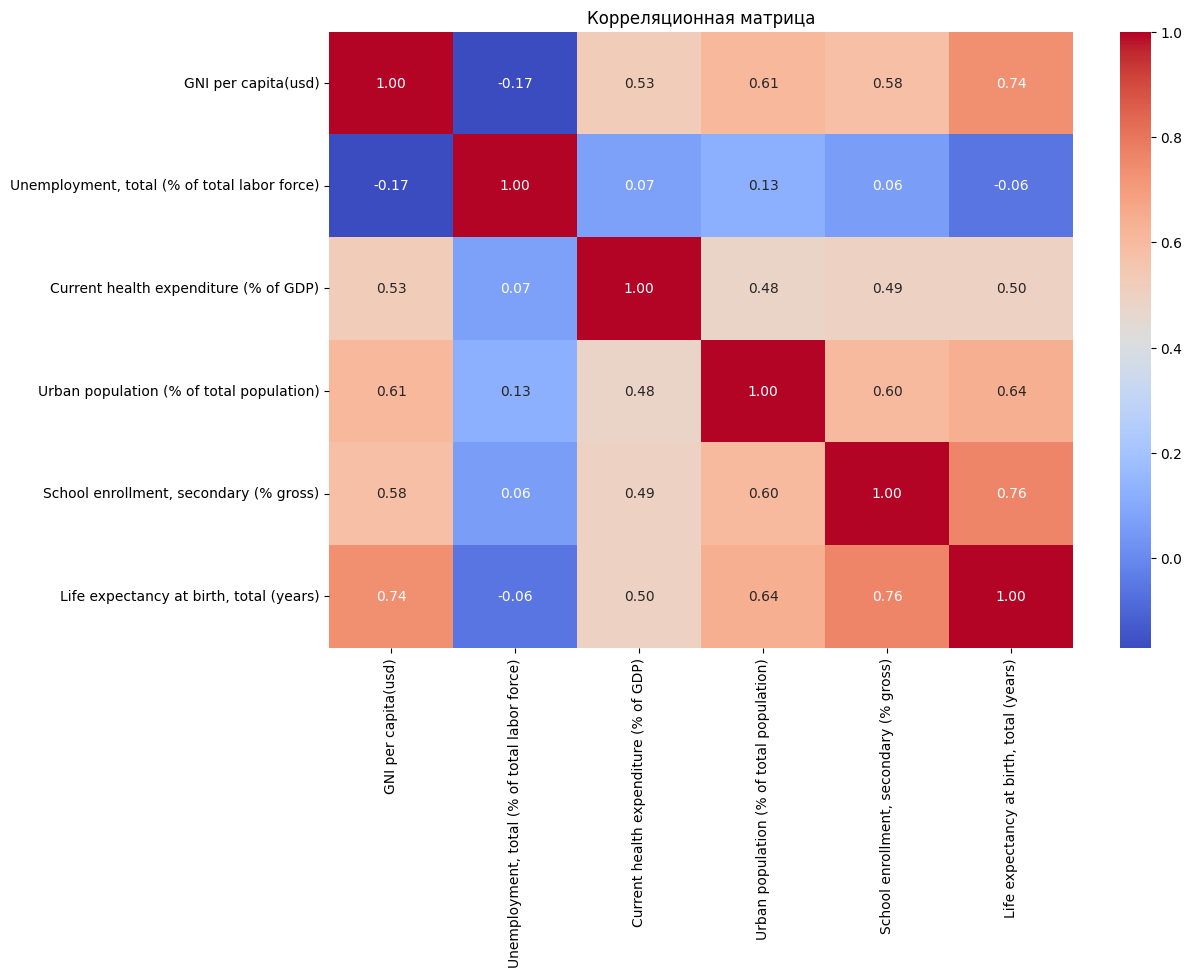


Корреляция с целевой переменной:
Life expectancy at birth, total (years)         1.000000
School enrollment, secondary (% gross)          0.763412
GNI per capita(usd)                             0.735705
Urban population (% of total population)        0.639741
Current health expenditure (% of GDP)           0.497261
Unemployment, total (% of total labor force)   -0.057928
Name: Life expectancy at birth, total (years), dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_scaled.corr(), annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Корреляционная матрица")
plt.show()

correlations = data_scaled.corr()['Life expectancy at birth, total (years)'].sort_values(ascending=False)
print("\nКорреляция с целевой переменной:")
print(correlations)

Наибольшее влияние на продолжительность жизни оказывают:
1. School enrollment (+0.76)
2. GNI per capita (+0.73)
3. Urban population (+0.64)

 Проверка мультиколлинеарности (VIF)

In [ ]:
X = data_scaled.drop('Life expectancy at birth, total (years)', axis=1)
X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print("\nПроверка мультиколлинеарности:")
print(vif_data)


Проверка мультиколлинеарности:
                                        Feature       VIF
0                                         const  1.000000
1                           GNI per capita(usd)  2.193245
2  Unemployment, total (% of total labor force)  1.153091
3         Current health expenditure (% of GDP)  1.551292
4      Urban population (% of total population)  2.016493
5        School enrollment, secondary (% gross)  1.850796


Мультиколлинеарность отсутствует, VIF < 5 для всех переменных.

# №3

Пошаговый отбор переменных

In [ ]:
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
y = data['Life expectancy at birth, total (years)']
X_stepwise = X.copy()

In [ ]:
while True:
    model_step = sm.OLS(y, sm.add_constant(X_stepwise)).fit()
    p_values = model_step.pvalues[1:]

    max_pval = p_values.max()
    if max_pval > 0.05:
        # удаляем переменную с максимальным p-value
        feature_to_remove = p_values.idxmax()
        X_stepwise = X_stepwise.drop(columns=[feature_to_remove])
    else:
        break

In [ ]:
final_model = sm.OLS(y, sm.add_constant(X_stepwise)).fit()
print(final_model.summary())

                                       OLS Regression Results                                      
Dep. Variable:     Life expectancy at birth, total (years)   R-squared:                       0.720
Model:                                                 OLS   Adj. R-squared:                  0.715
Method:                                      Least Squares   F-statistic:                     160.1
Date:                                     Thu, 09 Jan 2025   Prob (F-statistic):           2.05e-51
Time:                                             23:33:54   Log-Likelihood:                -523.68
No. Observations:                                      191   AIC:                             1055.
Df Residuals:                                          187   BIC:                             1068.
Df Model:                                                3                                         
Covariance Type:                                 nonrobust                                         


1. Итоговая регрессионая модель (ОLS)

Модель объясняет зависимость между ожидаемой продолжительностью жизни и тремя значимыми переменными:

* Уровнем ВНД на душу населения (GNI per capita(usd)).
* Уровнем урбанизации (Urban population (% of total population)).
* Охватом среднего образования (School enrollment, secondary (% gross)).


Ключевые показатели:

* R^2=0.720: Модель объясняет 72% вариации в ожидаемой продолжительности жизни, что свидетельствует о хорошей степени соответствия данных модели.
* Adj. R^2=0.715: Уточнённое значение R^2, учитывающее количество предикторов, также высоко.
* F-statistic = 160.1, p < 0.001: Модель в целом статистически значима.

2. Значимость коэффициентов:

* Константа: coef = 71.86, p < 0.001. Базовый уровень ожидаемой продолжительности жизни составляет около 72 лет (при нулевых значениях предикторов, что в данном случае скорее всего теоретическая константа).
* GNI per capita(usd):
    * coef = 2.7901,p < 0.001.
    * Увеличение ВНД на душу населения на 1 USD связано с увеличением ожидаемой продолжительности жизни на 2.79 года, при прочих равных.
* Urban population (% of total population):
    *  coef = 0.8695, p < 0.001.
    *  Увеличение доли городского населения на 1% связано с ростом ожидаемой продолжительности жизни на 0.86 года, при прочих равных.
* School enrollment, secondary (% gross):
    *  coef = 3.2771, p < 0.001.
    *  При увеличении охвата среднего образования на 1% ожидаемая продолжительность жизни увеличивается на 3ю28 года, при прочих равных.

Все предикторы значимы (p-value < 0.05).

Анализ остатков

In [ ]:
y_pred = final_model.predict(sm.add_constant(X_stepwise))
residuals = y - y_pred

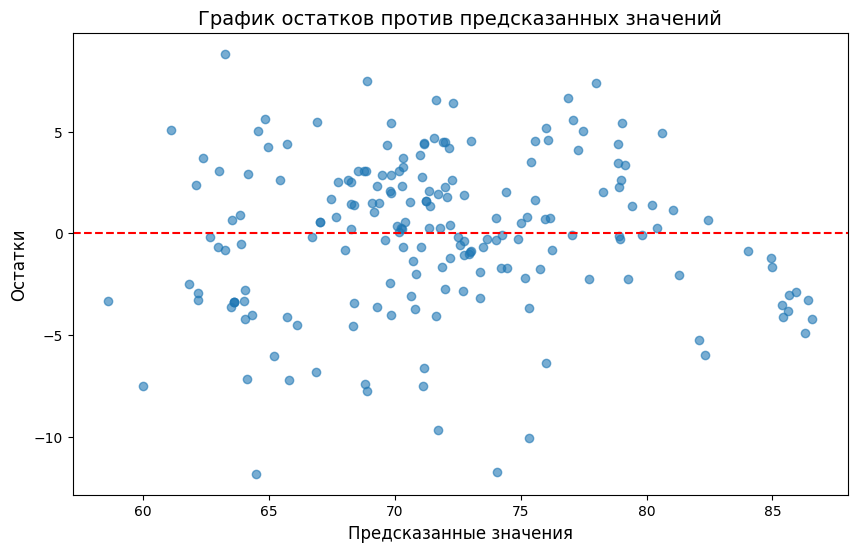

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('График остатков против предсказанных значений', fontsize=14)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Остатки', fontsize=12)
plt.show()

Модель адекватно объясняет данные.

Тест Бройша-Пагана

In [ ]:
bp_test = smd.het_breuschpagan(residuals, sm.add_constant(X_stepwise))
print("Тест Бройша-Пагана:")
print(f"p-value: {bp_test[1]}")

Тест Бройша-Пагана:
p-value: 0.6644175592742043


Тест Уайта

In [ ]:
white_test = smd.het_white(residuals, sm.add_constant(X_stepwise))
print("Тест Уайта:")
print(f"p-value: {white_test[1]}")

Тест Уайта:
p-value: 0.33715453861841244




Тест Бройша-Пагана (p = 0.664): Не указывает на наличие гетероскедастичности в остатках.

Тест Уайта (p = 0.337): Также подтверждает отсутствие гетероскедастичности.

Итог: Гетероскедастичность не обнаружена, что позволяет использовать исходные стандартные ошибки модели.

In [ ]:
if bp_test[1] < 0.05 or white_test[1] < 0.05:
    print("Обнаружена гетероскедастичность. Применяем поправку Уайта.")
    final_model_hc = final_model.get_robustcov_results(cov_type='HC3')
    print(final_model_hc.summary())
else:
    print("Гетероскедастичность не обнаружена. Используем исходные результаты модели.")

Гетероскедастичность не обнаружена. Используем исходные результаты модели.


График остатков против предсказанных значений показывает случайное распределение остатков вокруг нуля, что подтверждает отсутствие паттернов, связанных с моделью.

Omnibus (p = 0.016) и Jarque-Bera (p = 0.0174): Указывают на незначительные отклонения остатков от нормального распределения. Однако это не является серьёзным нарушением для линейной регрессии.

Durbin-Watson = 2.024: Автокорреляция остатков отсутствует.

In [ ]:
mse_manual = ((y - y_pred) ** 2).mean()
print(f"Mean Squared Error (MSE): {mse_manual}")


Mean Squared Error (MSE): 14.092683410097898


# №4

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
X = data_scaled[[
    'GNI per capita(usd)',
    'Unemployment, total (% of total labor force)',
    'Current health expenditure (% of GDP)',
    'Urban population (% of total population)',
    'School enrollment, secondary (% gross)'
]]
y = data_scaled['Life expectancy at birth, total (years)']

Разделение данных на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Ridge регрессия с кросс-валидацией

In [ ]:
ridge = Ridge()
ridge_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
ridge_mean_rmse = np.sqrt(-ridge_scores.mean())

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse_test = np.sqrt(mean_squared_error(y_test, ridge_pred))

Lasso регрессия с кросс-валидацией

In [ ]:
lasso = Lasso()
lasso_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lasso_mean_rmse = np.sqrt(-lasso_scores.mean())

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse_test = np.sqrt(mean_squared_error(y_test, lasso_pred))

In [ ]:
print("Ridge Regression:")
print(f"Mean RMSE (CV): {ridge_mean_rmse}")
print(f"R2 (Test): {ridge_r2}")
print(f"RMSE (Test): {ridge_rmse_test}")

print("\nLasso Regression:")
print(f"Mean RMSE (CV): {lasso_mean_rmse}")
print(f"R2 (Test): {lasso_r2}")
print(f"RMSE (Test): {lasso_rmse_test}")

Ridge Regression:
Mean RMSE (CV): 4.008670653037927
R2 (Test): 0.7004501279812263
RMSE (Test): 4.022511815894608

Lasso Regression:
Mean RMSE (CV): 4.063065329633789
R2 (Test): 0.7147418840339886
RMSE (Test): 3.9253805302404325


In [ ]:
print("\nComparison:")
print(f"Ridge RMSE: {ridge_rmse_test}, R2: {ridge_r2}")
print(f"Lasso RMSE: {lasso_rmse_test}, R2: {lasso_r2}")


Comparison:
Ridge RMSE: 4.022511815894608, R2: 0.7004501279812263
Lasso RMSE: 3.9253805302404325, R2: 0.7147418840339886


Lasso Regression имеет более высокое значение R^2 (0.7147 против 0.7004 у Ridge), что указывает на лучшее объяснение вариативности данных.
RMSE на тестовой выборке также ниже у Lasso (3.93 против 4.02), что говорит о меньшей средней ошибке прогнозов.

Анализ ошибок для лучшей модели (выбераем Lasso)

In [ ]:
best_model = 'Lasso' if lasso_r2 > ridge_r2 else 'Ridge'
best_model_pred = lasso_pred if lasso_r2 > ridge_r2 else ridge_pred
residuals = y_test - best_model_pred

In [ ]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Остатки vs Прогнозы

Text(0, 0.5, 'Residuals')

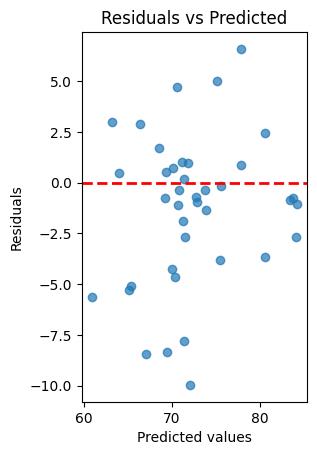

In [ ]:
plt.subplot(1, 2, 1)
plt.scatter(best_model_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

Точки распределены хаотично вокруг нуля, что свидетельствует об отсутствии явного систематического смещения модели.
Однако остатки имеют некоторую изменчивость, возможно, в зависимости от прогнозируемых значений.

Гистограмма остатков

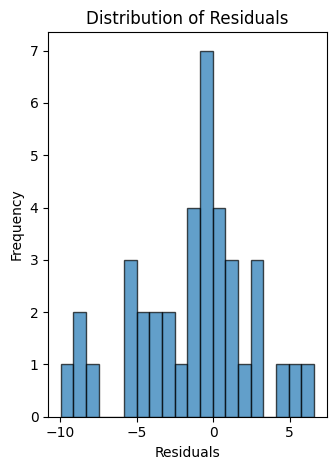

In [ ]:
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Остатки близки к нормальному распределению, но могут быть небольшие отклонения (например, более широкие хвосты).

Вывод:

Lasso Regression является предпочтительной моделью благодаря более высоким показателям качества (R^2 и RMSE).
Модель демонстрирует хорошую адаптацию к данным.

Итоговая интерпретация лучшей модели

In [ ]:
print("\nFinal Model Interpretation:")
if best_model == 'Lasso':
    print("The Lasso regression model was selected as the final model.")
    print(f"R2 (Test): {lasso_r2}")
    print(f"RMSE (Test): {lasso_rmse_test}")
    print("Lasso effectively performs variable selection and regularization, which helps to reduce overfitting and identify key predictors.")
else:
    print("The Ridge regression model was selected as the final model.")
    print(f"R2 (Test): {ridge_r2}")
    print(f"RMSE (Test): {ridge_rmse_test}")
    print("Ridge is effective at handling multicollinearity and stabilizing coefficient estimates.")


Final Model Interpretation:
The Lasso regression model was selected as the final model.
R2 (Test): 0.7147418840339886
RMSE (Test): 3.9253805302404325
Lasso effectively performs variable selection and regularization, which helps to reduce overfitting and identify key predictors.


В качестве финальной модели была выбрана Lasso-регрессия, так как она показала наилучшие результаты среди рассмотренных моделей. Коэффициент детерминации R^2 на тестовой выборке составил 0.7147, что указывает на то, что модель объясняет 71.47% вариации зависимой переменной ("Life expectancy at birth, total (years)"). Средняя ошибка прогноза (RMSE) составила 3.93, что свидетельствует о высокой точности предсказаний.

#№5

In [ ]:
from sklearn.metrics import mean_squared_error

ols_r2 = 0.720
ols_mse = 14.092683410097898
ridge_r2 = 0.700
ridge_mse = 4.022511815894608**2
lasso_r2 = 0.715
lasso_mse = 3.9253805302404325**2

Сравнение моделей на основе R2 и MSE

In [ ]:
model_results = pd.DataFrame({
    'Model': ['OLS (Stepwise)', 'Ridge Regression', 'Lasso Regression'],
    'R^2': [ols_r2, ridge_r2, lasso_r2],
    'MSE': [ols_mse, ridge_mse, lasso_mse]
})

Выбор лучшей модели на основе R^2 и MSE

In [ ]:
best_model = model_results.loc[model_results['R^2'].idxmax()]

In [ ]:
print("Результаты моделей:")
print(model_results)
print("\nЛучшая модель:")
print(best_model)

Результаты моделей:
              Model    R^2        MSE
0    OLS (Stepwise)  0.720  14.092683
1  Ridge Regression  0.700  16.180601
2  Lasso Regression  0.715  15.408612

Лучшая модель:
Model    OLS (Stepwise)
R^2                0.72
MSE           14.092683
Name: 0, dtype: object


OLS (Stepwise) — наиболее удачная модель, так как она обеспечивает наивысшее R^2(0.72) и минимальную ошибку (MSE=14.09).

Содержательная интерпретация OLS позволяет сделать конкретные выводы о влиянии предикторов на продолжительность жизни, что важно для принятия решений.